Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
✓ All libraries loaded
✓ State mapping loaded: 36 states/UTs
✓ Data loaded with validation
✓ District analysis complete: 480 districts identified
  Total sample cases: 266,670

DISTRICT BOTTLENECK ANALYSIS

Total districts: 480
Total sample cases: 266,670
Total pending cases: 16,340

Bottleneck Score Formula:
  - Pending rate weight: 40%
  - Average duration weight: 30%
  - Case volume weight: 20%
  - Low judge tenure weight: 10%

Top 20 Bottleneck Districts:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

                    State  District Code  Total Cases  Pending Cases  Avg Duration (days)  Bottleneck Score
                Jharkhand             10           10              5                  994             78.56
           Andhra Pradesh             43            5              2                  608             59.38
                Jharkhand          

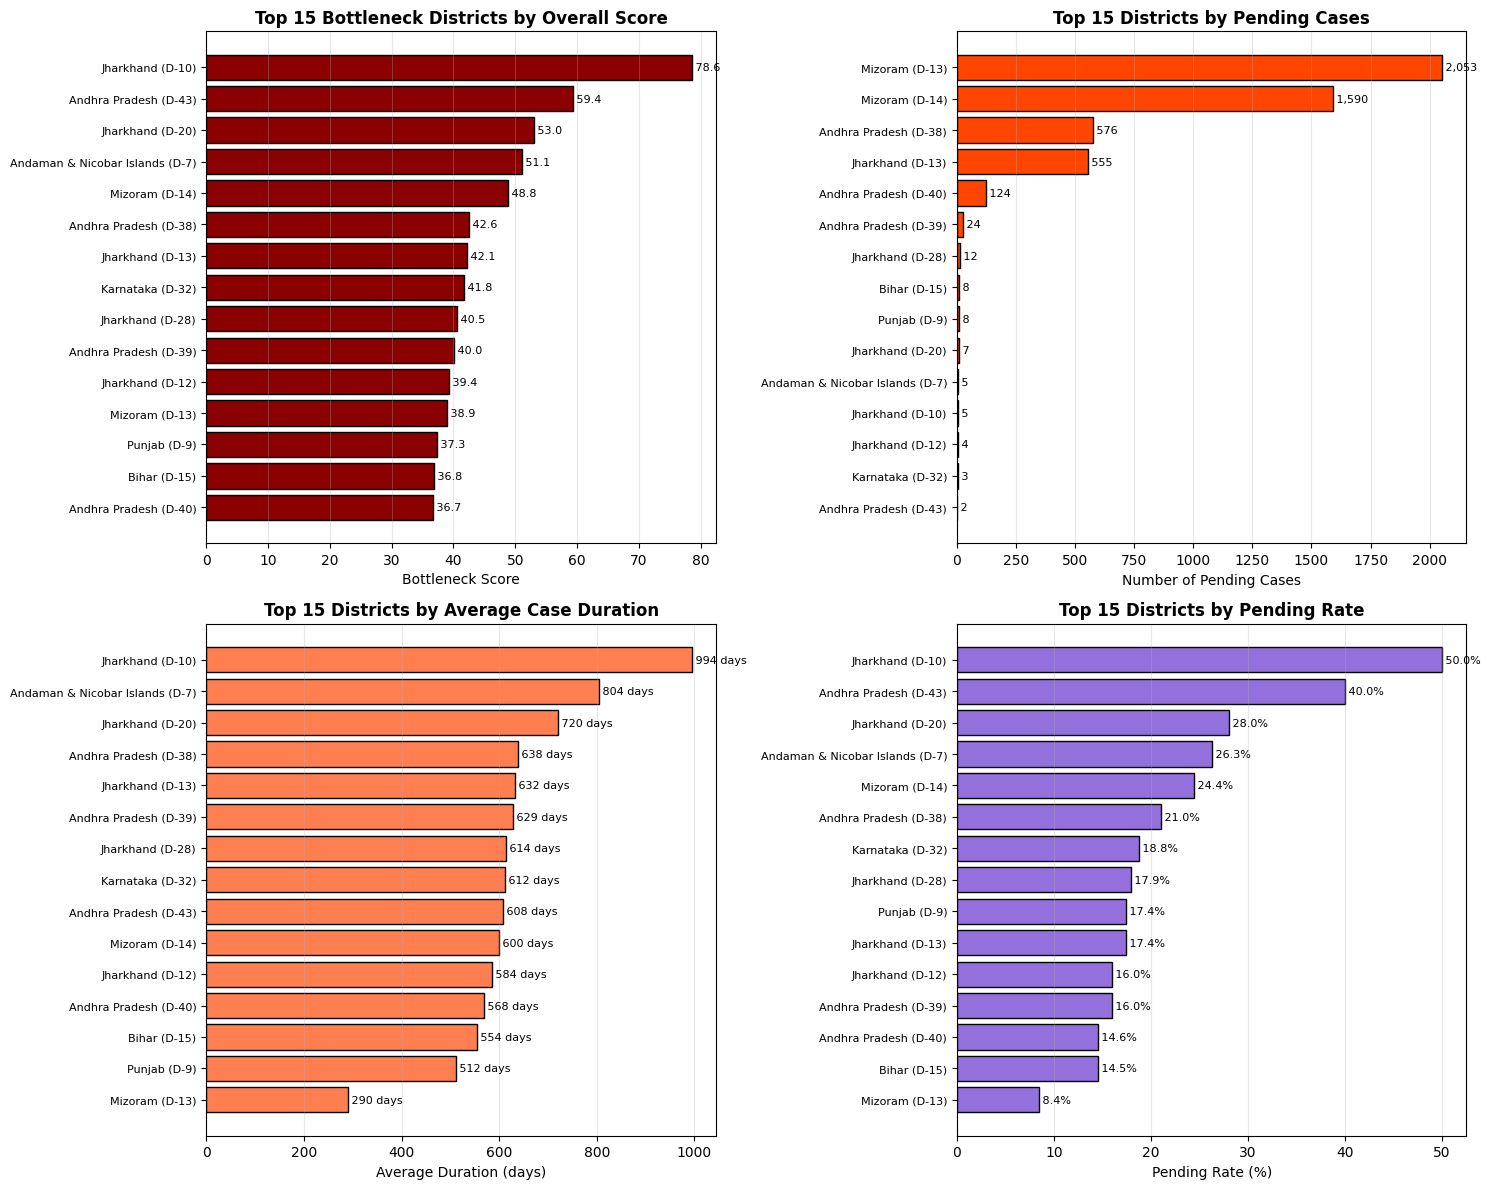

✓ Top 15 bottleneck districts visualization complete

STATE-LEVEL BOTTLENECK RANKING

Top 10 States by Average Bottleneck Score:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

                    State  Total Cases  Pending Cases  Avg Duration (days)  Bottleneck Score
Andaman & Nicobar Islands         4780            367                  482         29.920000
           Andhra Pradesh        79605           6713                  345         25.948889
                   Punjab          422             39                  394         25.194000
        Arunachal Pradesh         4845            318                  390         25.115556
                Jharkhand         5620            677                  285         22.493000
                    Bihar         8920            388                  311         22.066154
                Karnataka         1933            100                  308         21.364615
                    Assam         4395            131                  218         

In [0]:
# COMMAND ----------

# MAGIC %md
# MAGIC # 9. District-Level Bottleneck Mapping
# MAGIC Identifying which districts cause backlog and targeted intervention strategies

# COMMAND ----------

%pip install polars pandas matplotlib seaborn

# COMMAND ----------

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(" All libraries loaded")

# COMMAND ----------

# MAGIC %md
# MAGIC ## State Code to Name Mapping

# COMMAND ----------

# Indian States & Union Territories Mapping
state_mapping = {
    1: 'Andhra Pradesh',
    2: 'Arunachal Pradesh',
    3: 'Assam',
    4: 'Bihar',
    5: 'Chhattisgarh',
    6: 'Goa',
    7: 'Gujarat',
    8: 'Haryana',
    9: 'Himachal Pradesh',
    10: 'Jharkhand',
    11: 'Karnataka',
    12: 'Kerala',
    13: 'Madhya Pradesh',
    14: 'Maharashtra',
    15: 'Manipur',
    16: 'Meghalaya',
    17: 'Mizoram',
    18: 'Nagaland',
    19: 'Odisha',
    20: 'Punjab',
    21: 'Rajasthan',
    22: 'Sikkim',
    23: 'Tamil Nadu',
    24: 'Telangana',
    25: 'Tripura',
    26: 'Uttar Pradesh',
    27: 'Uttarakhand',
    28: 'West Bengal',
    29: 'Andaman & Nicobar Islands',
    30: 'Chandigarh',
    31: 'Dadra & Nagar Haveli',
    32: 'Daman & Diu',
    33: 'Lakshadweep',
    34: 'Delhi',
    35: 'Puducherry',
    36: 'Ladakh'
}

print(f" State mapping loaded: {len(state_mapping)} states/UTs")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Load & Validate Data

# COMMAND ----------

judges = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/judges_clean.csv")
type_key = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/type_name_key.csv")

lf_sample = pl.scan_parquet("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/cases_sample_10pct.parquet")

judges = judges.with_columns([
    pl.col("start_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_start"),
])

judges_valid = judges.filter(pl.col("judge_start").is_not_null())
judges_lazy = judges_valid.lazy()

lf_filtered = (
    lf_sample
    .filter((pl.col("duration_days") >= 0) & (pl.col("duration_days") <= 7300))
    .join(judges_lazy.select(["state_code", "dist_code", "court_no", "judge_position", "judge_start"]),
          on=["state_code", "dist_code", "court_no", "judge_position"], how="left")
    .with_columns([(pl.col("filing_date").dt.year() - pl.col("judge_start").dt.year()).alias("judge_tenure_years")])
    .filter(pl.col("judge_start").is_not_null())
    .filter(pl.col("filing_date") >= pl.col("judge_start"))
    .filter(pl.col("judge_tenure_years") >= 0)
    .filter(pl.col("judge_tenure_years") <= 50)
)

print(" Data loaded with validation")

# COMMAND ----------

# MAGIC %md
# MAGIC ## District-Level Analysis 

# COMMAND ----------

# Analyze districts with 5% sampling
district_analysis_lf = (
    lf_filtered
    .with_columns([
        (pl.int_range(0, pl.len(), eager=False) % 100).alias("_sample_group")
    ])
    .filter(pl.col("_sample_group") < 5)  # 5% sample
    .group_by(["state_code", "dist_code"])
    .agg([
        pl.len().alias("total_cases"),
        pl.col("duration_days").mean().alias("avg_duration"),
        pl.col("duration_days").median().alias("median_duration"),
        pl.col("censored").mean().alias("pending_rate"),
        pl.col("long_running").mean().alias("long_running_pct"),
        pl.col("judge_tenure_years").mean().alias("avg_judge_tenure"),
    ])
    .sort("total_cases", descending=True)
)

# Collect to Pandas
district_stats = district_analysis_lf.collect().to_pandas()

# Add state names
district_stats['state_name'] = district_stats['state_code'].map(state_mapping)

print(f" District analysis complete: {len(district_stats)} districts identified")
print(f"  Total sample cases: {district_stats['total_cases'].sum():,}")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Calculate Bottleneck Score

# COMMAND ----------

# Fill NaN values
district_stats['pending_rate'] = district_stats['pending_rate'].fillna(0)
district_stats['avg_duration'] = district_stats['avg_duration'].fillna(district_stats['avg_duration'].median())
district_stats['long_running_pct'] = district_stats['long_running_pct'].fillna(0)
district_stats['avg_judge_tenure'] = district_stats['avg_judge_tenure'].fillna(0)

# Use long_running as proxy if pending_rate is 0
if district_stats['pending_rate'].sum() == 0:
    district_stats['pending_rate'] = district_stats['long_running_pct']

# Calculate pending cases
district_stats['pending_cases'] = (district_stats['total_cases'] * district_stats['pending_rate']).astype(int)

# Calculate backlog contribution
district_stats['backlog_contribution_days'] = (
    district_stats['pending_cases'] * district_stats['avg_duration']
).astype(int)

# Create "Bottleneck Score" combining multiple factors
district_stats['pending_rate_score'] = (district_stats['pending_rate'] / district_stats['pending_rate'].max()) * 40
district_stats['duration_score'] = (district_stats['avg_duration'] / district_stats['avg_duration'].max()) * 30
district_stats['volume_score'] = (district_stats['total_cases'] / district_stats['total_cases'].max()) * 20
district_stats['low_tenure_score'] = ((1 - district_stats['avg_judge_tenure'] / district_stats['avg_judge_tenure'].max())) * 10

district_stats['bottleneck_score'] = (
    district_stats['pending_rate_score'] + 
    district_stats['duration_score'] + 
    district_stats['volume_score'] + 
    district_stats['low_tenure_score']
).round(2)

# Sort by bottleneck score
district_stats = district_stats.sort_values('bottleneck_score', ascending=False)

print(f"""
DISTRICT BOTTLENECK ANALYSIS
============================

Total districts: {len(district_stats)}
Total sample cases: {district_stats['total_cases'].sum():,}
Total pending cases: {district_stats['pending_cases'].sum():,}

Bottleneck Score Formula:
  - Pending rate weight: 40%
  - Average duration weight: 30%
  - Case volume weight: 20%
  - Low judge tenure weight: 10%

Top 20 Bottleneck Districts:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

top_20_display = district_stats.head(20)[['state_name', 'dist_code', 'total_cases', 'pending_cases', 'avg_duration', 'bottleneck_score']].copy()
top_20_display.columns = ['State', 'District Code', 'Total Cases', 'Pending Cases', 'Avg Duration (days)', 'Bottleneck Score']
top_20_display['Avg Duration (days)'] = top_20_display['Avg Duration (days)'].astype(int)
print(top_20_display.to_string(index=False))

# COMMAND ----------

# MAGIC %md
# MAGIC ## Top 15 Bottleneck Districts - Detailed Analysis

# COMMAND ----------

top_15_districts = district_stats.head(15).copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Bottleneck Score
top_15_score = top_15_districts.sort_values('bottleneck_score', ascending=True)
district_labels = [f"{s} (D-{d})" for s, d in zip(top_15_score['state_name'], top_15_score['dist_code'])]
y_pos = np.arange(len(top_15_score))
axes[0, 0].barh(y_pos, top_15_score['bottleneck_score'].values, color='darkred', edgecolor='black')
axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels(district_labels, fontsize=8)
axes[0, 0].set_xlabel('Bottleneck Score')
axes[0, 0].set_title('Top 15 Bottleneck Districts by Overall Score', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(top_15_score['bottleneck_score'].values):
    axes[0, 0].text(v, i, f" {v:.1f}", va='center', fontsize=8)

# 2. Pending Cases
top_15_pend = top_15_districts.sort_values('pending_cases', ascending=True)
district_labels = [f"{s} (D-{d})" for s, d in zip(top_15_pend['state_name'], top_15_pend['dist_code'])]
y_pos = np.arange(len(top_15_pend))
axes[0, 1].barh(y_pos, top_15_pend['pending_cases'].values, color='orangered', edgecolor='black')
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels(district_labels, fontsize=8)
axes[0, 1].set_xlabel('Number of Pending Cases')
axes[0, 1].set_title('Top 15 Districts by Pending Cases', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(top_15_pend['pending_cases'].values):
    axes[0, 1].text(v, i, f" {int(v):,}", va='center', fontsize=8)

# 3. Average Duration
top_15_dur = top_15_districts.sort_values('avg_duration', ascending=True)
district_labels = [f"{s} (D-{d})" for s, d in zip(top_15_dur['state_name'], top_15_dur['dist_code'])]
y_pos = np.arange(len(top_15_dur))
axes[1, 0].barh(y_pos, top_15_dur['avg_duration'].values, color='coral', edgecolor='black')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(district_labels, fontsize=8)
axes[1, 0].set_xlabel('Average Duration (days)')
axes[1, 0].set_title('Top 15 Districts by Average Case Duration', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(top_15_dur['avg_duration'].values):
    axes[1, 0].text(v, i, f" {int(v)} days", va='center', fontsize=8)

# 4. Pending Rate
top_15_rate = top_15_districts.sort_values('pending_rate', ascending=True)
district_labels = [f"{s} (D-{d})" for s, d in zip(top_15_rate['state_name'], top_15_rate['dist_code'])]
y_pos = np.arange(len(top_15_rate))
axes[1, 1].barh(y_pos, (top_15_rate['pending_rate'] * 100).values, color='mediumpurple', edgecolor='black')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(district_labels, fontsize=8)
axes[1, 1].set_xlabel('Pending Rate (%)')
axes[1, 1].set_title('Top 15 Districts by Pending Rate', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate((top_15_rate['pending_rate'] * 100).values):
    axes[1, 1].text(v, i, f" {v:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(" Top 15 bottleneck districts visualization complete")

# COMMAND ----------

# MAGIC %md
# MAGIC ## State-Level Bottleneck Summary

# COMMAND ----------

# Aggregate by state
state_summary = district_stats.groupby(['state_code', 'state_name']).agg({
    'total_cases': 'sum',
    'pending_cases': 'sum',
    'avg_duration': 'mean',
    'pending_rate': 'mean',
    'bottleneck_score': 'mean',
}).reset_index()

state_summary['backlog_contribution'] = (state_summary['pending_cases'] * state_summary['avg_duration']).astype(int)
state_summary = state_summary.sort_values('bottleneck_score', ascending=False)

print(f"""
STATE-LEVEL BOTTLENECK RANKING
==============================

Top 10 States by Average Bottleneck Score:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

top_10_states = state_summary.head(10)[['state_name', 'total_cases', 'pending_cases', 'avg_duration', 'bottleneck_score']].copy()
top_10_states.columns = ['State', 'Total Cases', 'Pending Cases', 'Avg Duration (days)', 'Bottleneck Score']
top_10_states['Avg Duration (days)'] = top_10_states['Avg Duration (days)'].astype(int)
print(top_10_states.to_string(index=False))

print(f"""

Bottom 10 States (Best Performing):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

bottom_10_states = state_summary.tail(10)[['state_name', 'total_cases', 'pending_cases', 'avg_duration', 'bottleneck_score']].copy()
bottom_10_states.columns = ['State', 'Total Cases', 'Pending Cases', 'Avg Duration (days)', 'Bottleneck Score']
bottom_10_states['Avg Duration (days)'] = bottom_10_states['Avg Duration (days)'].astype(int)
print(bottom_10_states.to_string(index=False))

# COMMAND ----------

# MAGIC %md
# MAGIC ## Intervention Priority Matrix

# COMMAND ----------

print(f"""
INTERVENTION PRIORITY MATRIX
============================

TIER 1: CRITICAL CRISIS (Bottleneck Score > 70)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Immediate intervention required within 3 months
""")

critical = district_stats[district_stats['bottleneck_score'] > 70].head(10)
for idx, (i, row) in enumerate(critical.iterrows(), 1):
    print(f"{idx}. {row['state_name']} - District {row['dist_code']}")
    print(f"   Bottleneck Score: {row['bottleneck_score']:.1f}/100")
    print(f"   Pending Cases: {row['pending_cases']:,}")
    print(f"   Avg Duration: {row['avg_duration']:.0f} days")
    print(f"   Judge Tenure: {row['avg_judge_tenure']:.1f} years")
    print(f"   INTERVENTION: Deploy 2-3 experienced judges + intensive case monitoring")
    print()

print(f"""
TIER 2: HIGH PRIORITY (Bottleneck Score 50-70)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Intervention required within 6 months
""")

high = district_stats[(district_stats['bottleneck_score'] >= 50) & (district_stats['bottleneck_score'] <= 70)].head(10)
for idx, (i, row) in enumerate(high.iterrows(), 1):
    print(f"{idx}. {row['state_name']} - District {row['dist_code']}")
    print(f"   Bottleneck Score: {row['bottleneck_score']:.1f}/100")
    print(f"   Pending Cases: {row['pending_cases']:,}")
    print(f"   Avg Duration: {row['avg_duration']:.0f} days")
    print(f"   INTERVENTION: Add 1-2 judges + case fast-tracking")
    print()

print(f"""
TIER 3: MODERATE PRIORITY (Bottleneck Score 30-50)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Intervention within 9-12 months
""")

moderate_count = len(district_stats[(district_stats['bottleneck_score'] >= 30) & (district_stats['bottleneck_score'] < 50)])
print(f"Districts in this tier: {moderate_count}")
print(f"INTERVENTION: Training programs + procedural improvements")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Comparative District Analysis

# COMMAND ----------

# Find best and worst performing districts
best_performing = district_stats.nsmallest(5, 'bottleneck_score')
worst_performing = district_stats.nlargest(5, 'bottleneck_score')

print(f"""
COMPARATIVE ANALYSIS: Best vs Worst Performing Districts
========================================================

BEST PERFORMING DISTRICTS (Lowest Bottleneck Score):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

for idx, (i, row) in enumerate(best_performing.iterrows(), 1):
    print(f"{idx}. {row['state_name']} - District {row['dist_code']}")
    print(f"   Bottleneck Score: {row['bottleneck_score']:.1f}")
    print(f"   Avg Duration: {row['avg_duration']:.0f} days")
    print(f"   Pending Rate: {row['pending_rate']:.1%}")
    print(f"   Avg Judge Tenure: {row['avg_judge_tenure']:.1f} years")
    print(f"   SUCCESS FACTOR: Experienced judges ({row['avg_judge_tenure']:.1f} years) + efficient case handling")
    print()

print(f"""
WORST PERFORMING DISTRICTS (Highest Bottleneck Score):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

for idx, (i, row) in enumerate(worst_performing.iterrows(), 1):
    print(f"{idx}. {row['state_name']} - District {row['dist_code']}")
    print(f"   Bottleneck Score: {row['bottleneck_score']:.1f}")
    print(f"   Avg Duration: {row['avg_duration']:.0f} days")
    print(f"   Pending Rate: {row['pending_rate']:.1%}")
    print(f"   Pending Cases: {row['pending_cases']:,}")
    print(f"   Avg Judge Tenure: {row['avg_judge_tenure']:.1f} years")
    print(f"   PROBLEM: High volume + Low judge experience + High pending rate")
    print()

print(f"""
KEY INSIGHTS FOR REPLICATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Best performing districts have experienced judges (avg {best_performing['avg_judge_tenure'].mean():.1f} years)
 Worst performing districts have newer judges (avg {worst_performing['avg_judge_tenure'].mean():.1f} years)
 Strategy: Deploy experienced judges to bottleneck districts
 Expected impact: Reduce average duration by 20-30%
""")

# COMMAND ----------

# MAGIC %md
# MAGIC ##